<a href="https://colab.research.google.com/github/misbakhulfajar27-killertheriper/Tugas_1/blob/main/Tugas_1_mechinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import files
uploaded = files.upload()

Saving dataset_tugas1_preprocessing.csv to dataset_tugas1_preprocessing (1).csv


In [15]:
# ============================================
# TAHAP 1: LOAD DATASET
# ============================================
# Nama : MISBAKHUL FAJAR
# NIM : 047996694
# Impor library yang diperlukan
import pandas as pd                  # untuk mengolah data berbentuk tabel (DataFrame)
import numpy as np                   # untuk operasi numerik
import matplotlib.pyplot as plt      # untuk membuat grafik
import seaborn as sns                # untuk visualisasi data yang lebih menarik
from sklearn.preprocessing import LabelEncoder          # untuk encoding label
from sklearn.model_selection import train_test_split    # untuk membagi data latih dan uji

# Membaca file CSV ke dalam DataFrame
df = pd.read_csv('dataset_tugas1_preprocessing.csv')

# Menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


In [16]:
# ============================================
# TAHAP 2: EKSPLORASI AWAL (EDA)
# ============================================

# --- 2.1 Cek struktur dan tipe data ---

# Menampilkan jumlah baris dan kolom
print("Jumlah baris dan kolom:", df.shape)
print()

# Menampilkan informasi kolom: nama kolom, jumlah data terisi, dan tipe data
df.info()

Jumlah baris dan kolom: (99, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB


In [17]:
# --- 2.2 Jumlah nilai hilang (missing values) per kolom ---

# Menghitung jumlah data kosong (NaN) pada setiap kolom
print("Jumlah nilai hilang per kolom:")
print(df.isnull().sum())

# Menghitung persentase data kosong pada setiap kolom
print()
print("Persentase nilai hilang per kolom (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

Jumlah nilai hilang per kolom:
ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64

Persentase nilai hilang per kolom (%):
ID                0.00
Nama              0.00
Jenis_Kelamin     0.00
Prodi             0.00
Status            0.00
Nilai_Akhir      29.29
Tanggal_Ujian     0.00
Umur              9.09
dtype: float64


In [18]:
# --- 2.3 Statistik deskriptif ---

# Statistik deskriptif untuk kolom numerik (count, mean, std, min, kuartil, max)
print("Statistik deskriptif kolom numerik:")
print(df.describe())

# Statistik deskriptif untuk kolom kategorikal/teks
# (count, unique = jumlah kategori berbeda, top = nilai paling sering, freq = frekuensinya)
print()
print("Statistik deskriptif kolom kategorikal:")
print(df.describe(include='object'))

Statistik deskriptif kolom numerik:
            Umur
count  90.000000
mean   23.366667
std     3.763963
min    18.000000
25%    20.000000
50%    23.000000
75%    26.000000
max    30.000000

Statistik deskriptif kolom kategorikal:
           ID Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
count      99   99            99               99     99          70   
unique     99   10             2                4      4           5   
top     MH001  Eka     Laki-laki  Teknik Komputer   Cuti           C   
freq        1   15            50               28     29          17   

       Tanggal_Ujian  
count             99  
unique            97  
top       2020/03/31  
freq               2  


In [19]:
# ============================================
# TAHAP 3: MENANGANI MISSING VALUES
# ============================================

# --- Imputasi kolom Umur (numerik) dengan MEDIAN ---
# Median dipilih karena tidak terpengaruh nilai ekstrem (outlier)
median_umur = df['Umur'].median()
df['Umur'] = df['Umur'].fillna(median_umur)

# --- Imputasi kolom Nilai_Akhir (kategorikal) dengan MODUS ---
# Modus (nilai yang paling sering muncul) cocok untuk data kategorikal
modus_nilai = df['Nilai_Akhir'].mode()[0]
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(modus_nilai)

# Menampilkan nilai yang dipakai untuk mengisi
print("Median Umur yang dipakai   :", median_umur)
print("Modus Nilai_Akhir yang dipakai:", modus_nilai)

# --- Verifikasi: pastikan tidak ada lagi nilai hilang ---
print()
print("Jumlah nilai hilang setelah imputasi:")
print(df.isnull().sum())

Median Umur yang dipakai   : 23.0
Modus Nilai_Akhir yang dipakai: C

Jumlah nilai hilang setelah imputasi:
ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


In [20]:
# ============================================
# TAHAP 4: NORMALISASI FORMAT TANGGAL
# ============================================

# Kolom Tanggal_Ujian memiliki 2 format campuran:
#   - yyyy/mm/dd  (contoh: 2020/12/11)
#   - dd-mm-yyyy  (contoh: 13-04-2020)

# Langkah 1: Konversi format yyyy/mm/dd
# errors='coerce' -> data yang tidak cocok dengan format diubah menjadi NaT (kosong)
tgl_format1 = pd.to_datetime(df['Tanggal_Ujian'], format='%Y/%m/%d', errors='coerce')

# Langkah 2: Konversi format dd-mm-yyyy
tgl_format2 = pd.to_datetime(df['Tanggal_Ujian'], format='%d-%m-%Y', errors='coerce')

# Langkah 3: Gabungkan kedua hasil
# fillna: bagian yang kosong pada format1 diisi dari hasil format2
df['Tanggal_Ujian'] = tgl_format1.fillna(tgl_format2)

# --- Verifikasi ---
# Pastikan tipe data sudah datetime
print("Tipe data Tanggal_Ujian:", df['Tanggal_Ujian'].dtype)

# Pastikan tidak ada tanggal yang gagal dikonversi
print("Jumlah tanggal gagal dikonversi:", df['Tanggal_Ujian'].isnull().sum())

# Tampilkan rentang tanggal dan 5 baris pertama
print("Tanggal paling awal :", df['Tanggal_Ujian'].min())
print("Tanggal paling akhir:", df['Tanggal_Ujian'].max())
print()
print(df[['ID', 'Tanggal_Ujian']].head())

Tipe data Tanggal_Ujian: datetime64[ns]
Jumlah tanggal gagal dikonversi: 0
Tanggal paling awal : 2020-01-05 00:00:00
Tanggal paling akhir: 2022-12-31 00:00:00

      ID Tanggal_Ujian
0  MH001    2020-04-13
1  MH002    2020-12-11
2  MH003    2021-11-21
3  MH004    2021-08-19
4  MH005    2020-01-05


In [21]:
# ============================================
# TAHAP 5: ENCODING LABEL (LABEL ENCODING)
# ============================================

# Membuat salinan DataFrame agar data asli (df) tetap berisi teks
# df asli akan dipakai lagi untuk visualisasi di Tahap 7
df_encoded = df.copy()

# Daftar kolom kategorikal yang akan di-encoding
kolom_kategorikal = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

# Dictionary untuk menyimpan encoder tiap kolom (berguna untuk melihat arti angkanya)
encoders = {}

# Melakukan Label Encoding pada setiap kolom kategorikal
for kolom in kolom_kategorikal:
    le = LabelEncoder()                                      # membuat objek encoder
    df_encoded[kolom] = le.fit_transform(df_encoded[kolom])  # ubah teks menjadi angka
    encoders[kolom] = le                                     # simpan encoder

# --- Menampilkan pemetaan label -> angka untuk setiap kolom ---
for kolom in kolom_kategorikal:
    print(f"Pemetaan kolom {kolom}:")
    for angka, label in enumerate(encoders[kolom].classes_):
        print(f"   {label} -> {angka}")
    print()

# --- Verifikasi hasil encoding ---
print("Tipe data setelah encoding:")
print(df_encoded.dtypes)
print()
print(df_encoded.head())

Pemetaan kolom Nama:
   Adi -> 0
   Budi -> 1
   Citra -> 2
   Dina -> 3
   Eka -> 4
   Farhan -> 5
   Gita -> 6
   Hana -> 7
   Iwan -> 8
   Joko -> 9

Pemetaan kolom Jenis_Kelamin:
   Laki-laki -> 0
   Perempuan -> 1

Pemetaan kolom Prodi:
   Data Science -> 0
   Informatika -> 1
   Sistem Informasi -> 2
   Teknik Komputer -> 3

Pemetaan kolom Status:
   Aktif -> 0
   Cuti -> 1
   DO -> 2
   Lulus -> 3

Pemetaan kolom Nilai_Akhir:
   A -> 0
   B -> 1
   C -> 2
   D -> 3
   E -> 4

Tipe data setelah encoding:
ID                       object
Nama                      int64
Jenis_Kelamin             int64
Prodi                     int64
Status                    int64
Nilai_Akhir               int64
Tanggal_Ujian    datetime64[ns]
Umur                    float64
dtype: object

      ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
0  MH001     8              0      3       0            2    2020-04-13  23.0
1  MH002     4              1      3       3            4

In [22]:
# ============================================
# TAHAP 6: SPLIT DATA (80% LATIH - 20% UJI)
# ============================================

# Membagi data menjadi data latih (train) dan data uji (test)
# test_size=0.2    -> 20% data dipakai sebagai data uji, 80% sebagai data latih
# random_state=42  -> mengunci pengacakan agar hasil split selalu sama (reproducible)
data_latih, data_uji = train_test_split(df_encoded, test_size=0.2, random_state=42)

# --- Verifikasi ukuran hasil split ---
print("Jumlah seluruh data :", len(df_encoded))
print("Jumlah data latih   :", len(data_latih), f"({len(data_latih)/len(df_encoded)*100:.1f}%)")
print("Jumlah data uji     :", len(data_uji), f"({len(data_uji)/len(df_encoded)*100:.1f}%)")

# Menampilkan 5 baris pertama dari masing-masing data
print()
print("5 baris pertama data latih:")
print(data_latih.head())
print()
print("5 baris pertama data uji:")
print(data_uji.head())

Jumlah seluruh data : 99
Jumlah data latih   : 79 (79.8%)
Jumlah data uji     : 20 (20.2%)

5 baris pertama data latih:
       ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
49  MH050     4              1      1       2            2    2021-10-01  21.0
70  MH071     5              0      1       2            2    2021-08-15  19.0
68  MH069     7              1      1       1            1    2022-01-21  24.0
15  MH016     4              0      2       3            4    2020-02-11  19.0
39  MH040     2              0      1       1            2    2022-03-21  29.0

5 baris pertama data uji:
       ID  Nama  Jenis_Kelamin  Prodi  Status  Nilai_Akhir Tanggal_Ujian  Umur
62  MH063     4              1      0       1            3    2020-06-11  25.0
40  MH041     6              0      3       2            2    2021-03-26  22.0
95  MH096     0              0      2       3            2    2021-04-14  20.0
18  MH019     5              1      1       2            2    2

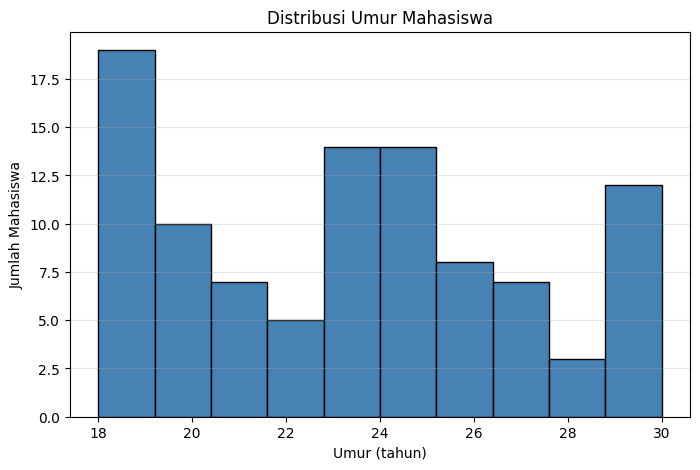

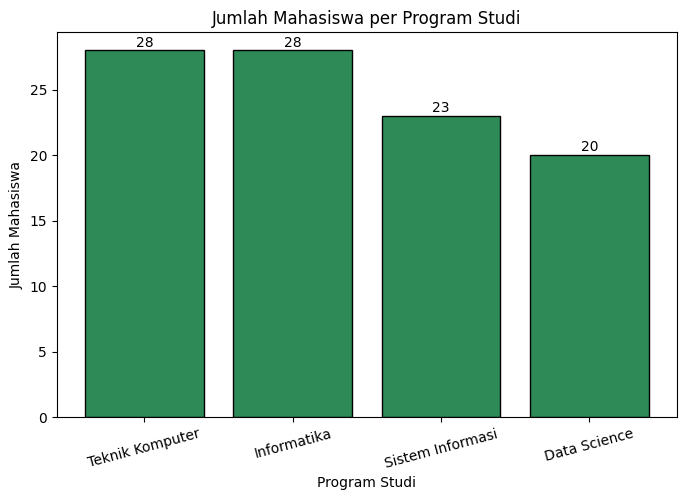

Prodi
Teknik Komputer     28
Informatika         28
Sistem Informasi    23
Data Science        20
Name: count, dtype: int64


In [23]:
# ============================================
# TAHAP 7: VISUALISASI
# ============================================

# --- 7.1 Histogram kolom Umur ---

plt.figure(figsize=(8, 5))                       # ukuran grafik (lebar, tinggi)
plt.hist(df['Umur'], bins=10, color='steelblue', edgecolor='black')  # histogram dengan 10 interval
plt.title('Distribusi Umur Mahasiswa')           # judul grafik
plt.xlabel('Umur (tahun)')                       # label sumbu X
plt.ylabel('Jumlah Mahasiswa')                   # label sumbu Y
plt.grid(axis='y', alpha=0.3)                    # garis bantu horizontal tipis
plt.show()                                       # tampilkan grafik


# --- 7.2 Grafik batang jumlah mahasiswa per Prodi ---

# Menghitung jumlah mahasiswa pada setiap Prodi
jumlah_prodi = df['Prodi'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(jumlah_prodi.index, jumlah_prodi.values, color='seagreen', edgecolor='black')

# Menampilkan angka jumlah di atas setiap batang
for i, nilai in enumerate(jumlah_prodi.values):
    plt.text(i, nilai + 0.3, str(nilai), ha='center')

plt.title('Jumlah Mahasiswa per Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=15)                          # miringkan label agar tidak bertumpuk
plt.show()

# Menampilkan angka pastinya dalam bentuk tabel
print(jumlah_prodi)